# 01a — Exploratory Data Analysis
**Project:** Student Attrition Prediction POC  
**Dataset:** Open University Learning Analytics Dataset (OULAD)  
**Training snapshot:** Week 6 = Day 42 (all features computed from date ≤ 42)

**Date semantics:** All `date` columns in OULAD are integers representing days relative to course start. Negative = before course start.

| Checkpoint | Day |
|-----------|-----|
| Week 2 | 14 |
| Week 4 | 28 |
| **Week 6 (training snapshot)** | **42** |
| Week 8 | 56 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('../data/raw')
FIG_DIR = Path('../docs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

WEEK6_DAY = 42

## Section 1: Data Loading

In [2]:
# --- studentInfo (anchor table) ---
info_dtypes = {
    'code_module': 'category',
    'code_presentation': 'category',
    'id_student': 'int32',
    'gender': 'category',
    'region': 'category',
    'highest_education': 'category',
    'imd_band': 'category',
    'age_band': 'category',
    'num_of_prev_attempts': 'int8',
    'studied_credits': 'int16',
    'disability': 'category',
    'final_result': 'category'
}
info = pd.read_csv(DATA_DIR / 'studentInfo.csv', dtype=info_dtypes)
print(f'studentInfo:        {info.shape[0]:>7,} rows × {info.shape[1]} cols  |  {info.memory_usage(deep=True).sum()/1e6:.1f} MB')

# --- studentAssessment ---
assess_dtypes = {
    'id_assessment': 'int32',
    'id_student': 'int32',
    'date_submitted': 'float32',
    'is_banked': 'int8',
    'score': 'float32'
}
student_assess = pd.read_csv(DATA_DIR / 'studentAssessment.csv', dtype=assess_dtypes)
print(f'studentAssessment:  {student_assess.shape[0]:>7,} rows × {student_assess.shape[1]} cols  |  {student_assess.memory_usage(deep=True).sum()/1e6:.1f} MB')

# --- assessments metadata ---
assessments = pd.read_csv(DATA_DIR / 'assessments.csv')
assessments['code_module'] = assessments['code_module'].astype('category')
assessments['code_presentation'] = assessments['code_presentation'].astype('category')
print(f'assessments:        {assessments.shape[0]:>7,} rows × {assessments.shape[1]} cols')

# --- courses ---
courses = pd.read_csv(DATA_DIR / 'courses.csv')
courses['code_module'] = courses['code_module'].astype('category')
courses['code_presentation'] = courses['code_presentation'].astype('category')
print(f'courses:            {courses.shape[0]:>7,} rows × {courses.shape[1]} cols')

# --- studentRegistration ---
reg_dtypes = {
    'code_module': 'category',
    'code_presentation': 'category',
    'id_student': 'int32',
    'date_registration': 'float32',
    'date_unregistration': 'float32'
}
registration = pd.read_csv(DATA_DIR / 'studentRegistration.csv', dtype=reg_dtypes)
print(f'studentRegistration:{registration.shape[0]:>7,} rows × {registration.shape[1]} cols')

# --- vle metadata ---
vle_meta = pd.read_csv(DATA_DIR / 'vle.csv')
print(f'vle:                {vle_meta.shape[0]:>7,} rows × {vle_meta.shape[1]} cols')

# --- studentVle (large — dtype-optimized load + immediate aggregation) ---
print('\nLoading studentVle.csv (10.6M rows) — this takes ~30s ...')
vle_dtypes = {
    'code_module': 'category',
    'code_presentation': 'category',
    'id_student': 'int32',
    'id_site': 'int32',
    'date': 'int16',
    'sum_click': 'int32'
}
vle_raw = pd.read_csv(DATA_DIR / 'studentVle.csv', dtype=vle_dtypes)
print(f'studentVle (raw):   {vle_raw.shape[0]:>7,} rows  |  {vle_raw.memory_usage(deep=True).sum()/1e6:.1f} MB')

# Aggregate to daily totals per student-module-date (collapses multiple site visits same day)
# observed=True required in pandas 2.x to avoid Cartesian category explosion
daily_vle = (
    vle_raw
    .groupby(['code_module', 'code_presentation', 'id_student', 'date'], observed=True)['sum_click']
    .sum()
    .reset_index()
)
del vle_raw
print(f'daily_vle (agg):    {daily_vle.shape[0]:>7,} rows  |  {daily_vle.memory_usage(deep=True).sum()/1e6:.1f} MB')

studentInfo:         32,593 rows × 12 cols  |  0.5 MB
studentAssessment:  173,912 rows × 5 cols  |  3.0 MB
assessments:            206 rows × 6 cols
courses:                 22 rows × 3 cols
studentRegistration: 32,593 rows × 5 cols
vle:                  6,364 rows × 6 cols

Loading studentVle.csv (10.6M rows) — this takes ~30s ...


studentVle (raw):   10,655,280 rows  |  170.5 MB


daily_vle (agg):    1,808,119 rows  |  21.7 MB


## Section 2: Target Variable Distribution

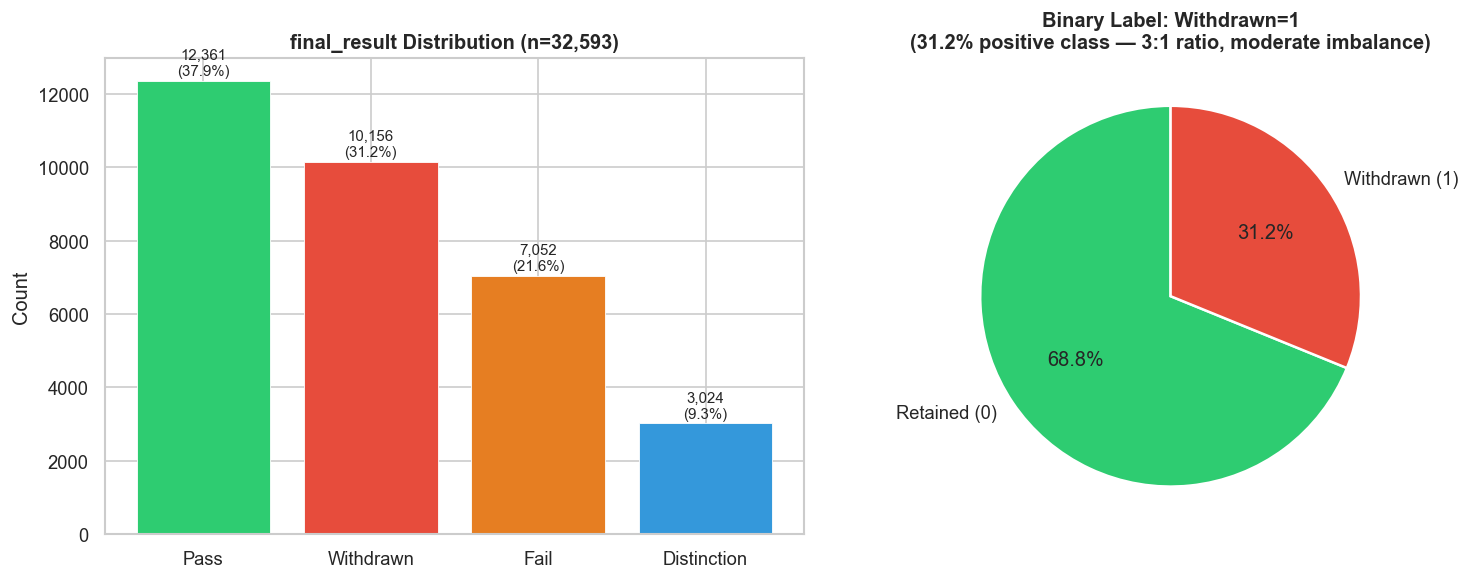

NOTE: 31.2% positive class = 3:1 ratio. SMOTE planned for Phase 3 but may be optional.
Withdrawn: 10,156  |  Retained: 22,437


In [3]:
# Binary label: Withdrawn = 1, all others = 0
info['label'] = (info['final_result'] == 'Withdrawn').astype('int8')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: multiclass counts
order = ['Pass', 'Withdrawn', 'Fail', 'Distinction']
colors = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db']
counts = info['final_result'].value_counts().reindex(order)
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('final_result Distribution (n=32,593)', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f'{val:,}\n({val/len(info)*100:.1f}%)', ha='center', fontsize=9)

# Right: binary label
binary_counts = info['label'].value_counts()
axes[1].pie(
    binary_counts.values,
    labels=['Retained (0)', 'Withdrawn (1)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Binary Label: Withdrawn=1\n(31.2% positive class — 3:1 ratio, moderate imbalance)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('NOTE: 31.2% positive class = 3:1 ratio. SMOTE planned for Phase 3 but may be optional.')
print(f'Withdrawn: {counts["Withdrawn"]:,}  |  Retained: {len(info) - counts["Withdrawn"]:,}')

## Section 3: Missing Value Analysis

In [4]:
def missing_summary(df, name):
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        return None
    pct = (missing / len(df) * 100).round(2)
    return pd.DataFrame({
        'file': name,
        'column': missing.index,
        'null_count': missing.values,
        'null_pct': pct.values
    })

frames = [
    missing_summary(info, 'studentInfo'),
    missing_summary(student_assess, 'studentAssessment'),
    missing_summary(assessments, 'assessments'),
    missing_summary(registration, 'studentRegistration'),
    missing_summary(daily_vle, 'daily_vle'),
]
missing_df = pd.concat([f for f in frames if f is not None], ignore_index=True)
display(missing_df.to_string(index=False))

print('\n--- Imputation Strategy ---')
print('imd_band (3.4% null): add imd_band_missing binary indicator; impute mode per (code_module, code_presentation) group')
print('studentAssessment.score (0.1%): cross-ref is_banked; non-banked nulls = likely non-submissions → impute 0')
print('assessments.date (5.3%): all Exam type → excluded by day-42 window filter automatically')
print('studentRegistration.date_unregistration (69%): expected — null = student did NOT withdraw')

'               file              column  null_count  null_pct\n        studentInfo            imd_band        1111      3.41\n  studentAssessment               score         173      0.10\n        assessments                date          11      5.34\nstudentRegistration   date_registration          45      0.14\nstudentRegistration date_unregistration       22521     69.10'


--- Imputation Strategy ---
imd_band (3.4% null): add imd_band_missing binary indicator; impute mode per (code_module, code_presentation) group
studentAssessment.score (0.1%): cross-ref is_banked; non-banked nulls = likely non-submissions → impute 0
assessments.date (5.3%): all Exam type → excluded by day-42 window filter automatically
studentRegistration.date_unregistration (69%): expected — null = student did NOT withdraw


## Section 4: Withdrawal Rate by Demographic

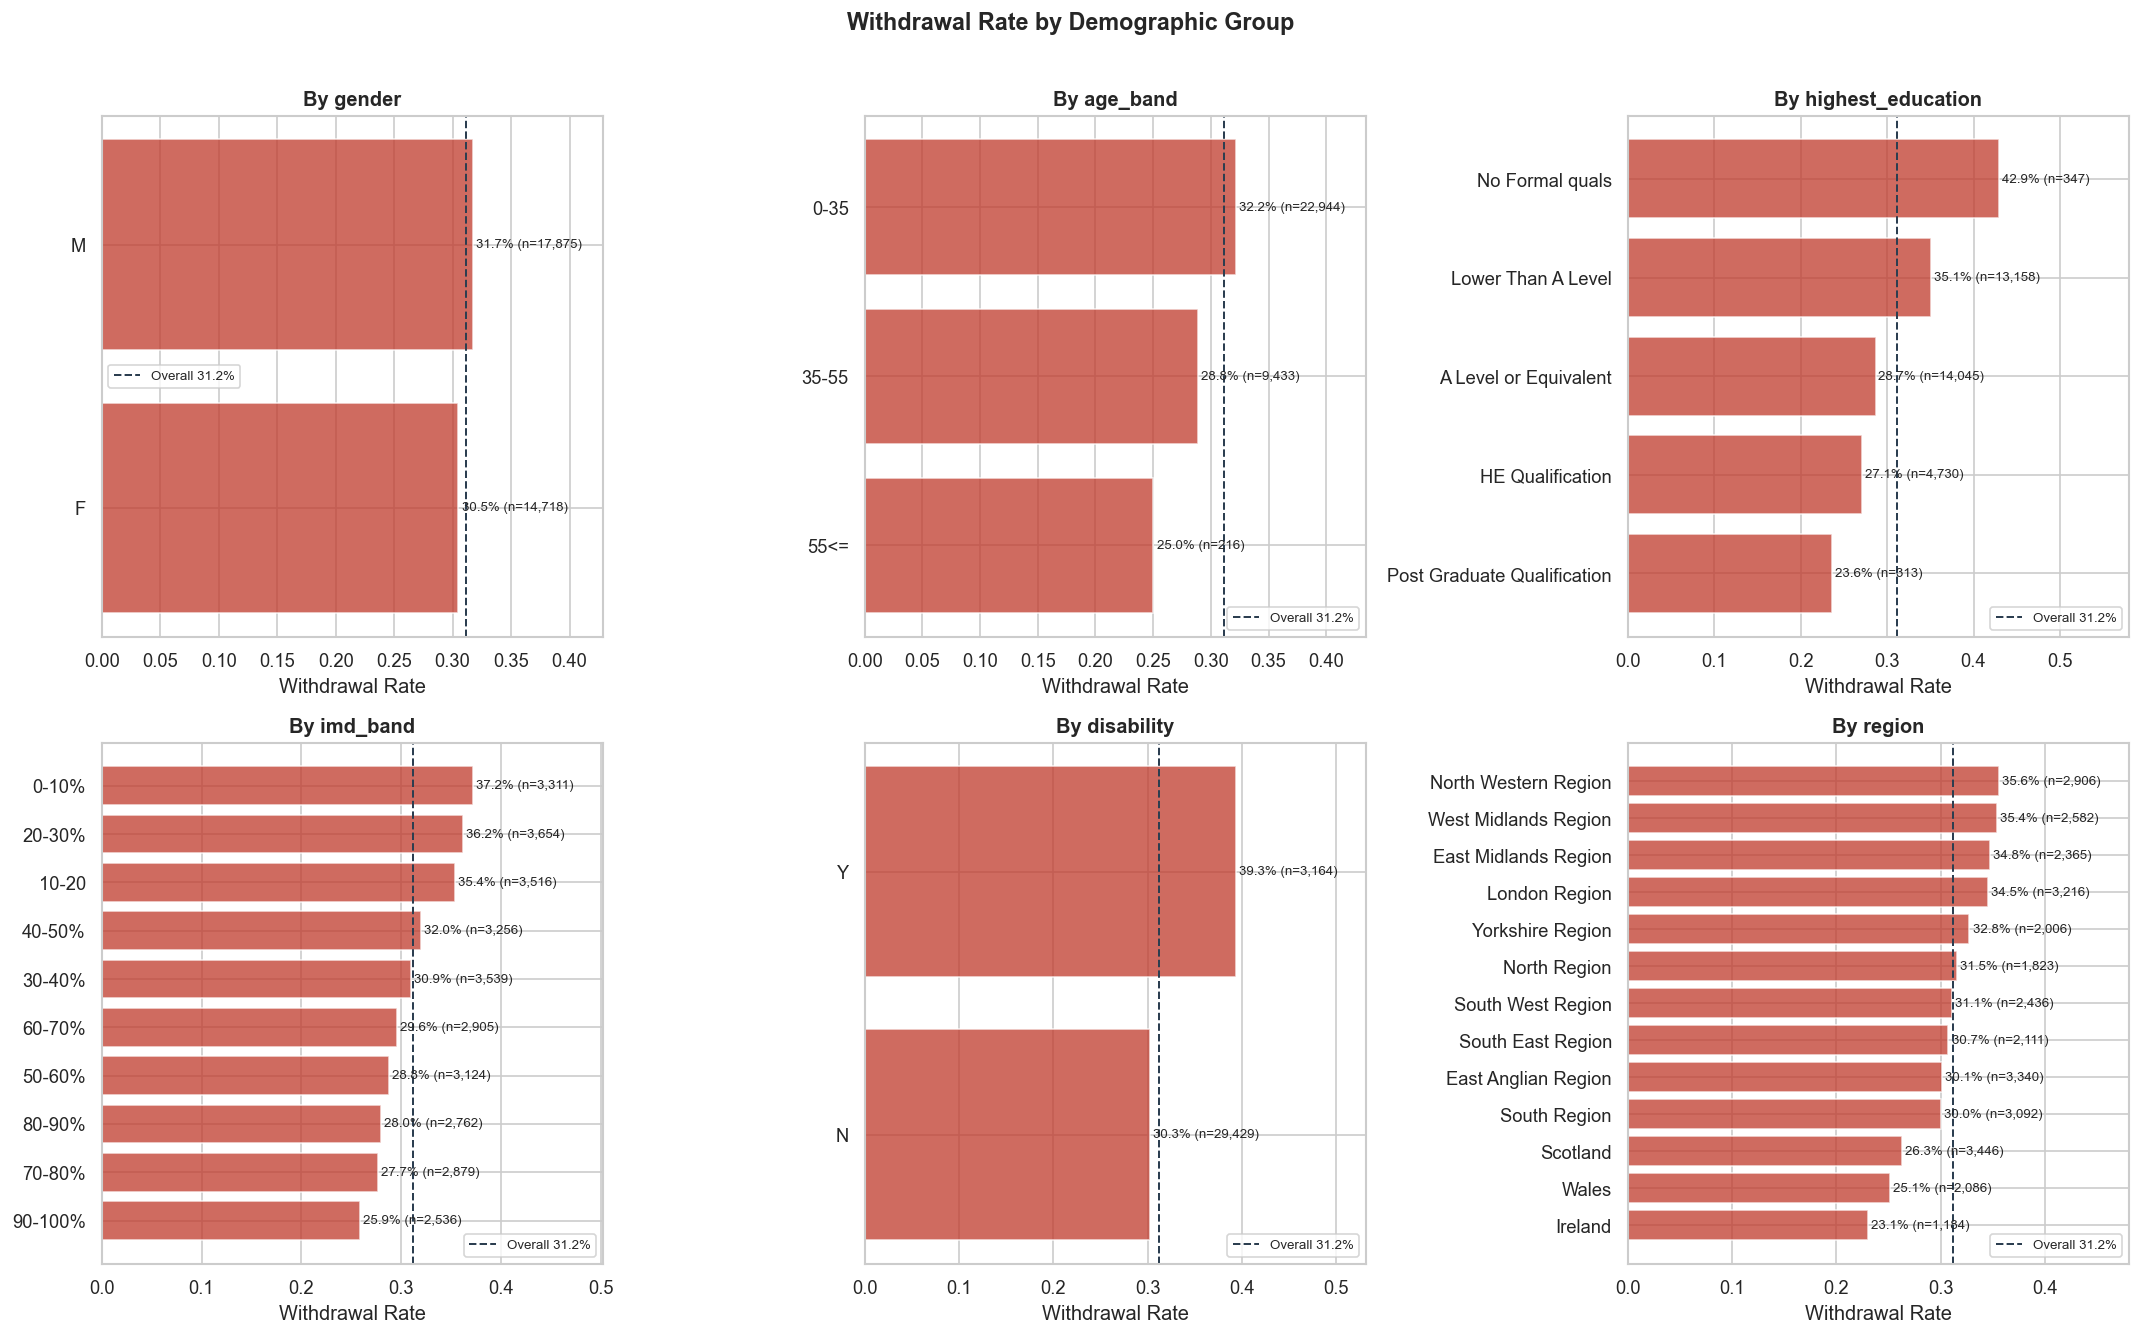

IMD Band withdrawal rates (primary bias audit axis):
          n_withdrawn  n_total      rate
imd_band                                
90-100%           656     2536  0.258675
70-80%            797     2879  0.276832
80-90%            774     2762  0.280232
50-60%            899     3124  0.287772
60-70%            859     2905  0.295697
30-40%           1095     3539  0.309409
40-50%           1042     3256  0.320025
10-20            1246     3516  0.354380
20-30%           1321     3654  0.361522
0-10%            1231     3311  0.371791


In [5]:
def withdrawal_rate_by(df, col):
    grouped = df.groupby(col, observed=True)['label'].agg(['sum', 'count'])
    grouped['rate'] = grouped['sum'] / grouped['count']
    return grouped.sort_values('rate', ascending=True)

demographics = ['gender', 'age_band', 'highest_education', 'imd_band', 'disability', 'region']
overall_rate = info['label'].mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, col in zip(axes.flatten(), demographics):
    rates = withdrawal_rate_by(info, col)
    bars = ax.barh(rates.index.astype(str), rates['rate'], color='#c0392b', alpha=0.75, edgecolor='white')
    ax.axvline(overall_rate, color='#2c3e50', linestyle='--', linewidth=1.2, label=f'Overall {overall_rate:.1%}')
    ax.set_xlabel('Withdrawal Rate')
    ax.set_title(f'By {col}', fontweight='bold')
    ax.legend(fontsize=8)
    for bar, (_, row) in zip(bars, rates.iterrows()):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f'{row["rate"]:.1%} (n={int(row["count"]):,})', va='center', fontsize=8)
    ax.set_xlim(0, rates['rate'].max() * 1.35)

plt.suptitle('Withdrawal Rate by Demographic Group', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'withdrawal_by_demographic.png', dpi=150, bbox_inches='tight')
plt.show()

# IMD band key finding (primary bias audit axis)
imd_rates = withdrawal_rate_by(info, 'imd_band')
print('IMD Band withdrawal rates (primary bias audit axis):')
print(imd_rates[['sum','count','rate']].rename(columns={'sum':'n_withdrawn','count':'n_total'}).to_string())

## Section 5: VLE Activity Overview

Students with zero VLE activity by week 6: 4,429 (13.6%)
Students with pre-course VLE activity: 23,809


C:\Users\jeged\AppData\Local\Temp\ipykernel_443864\142803410.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pre_course_rate = plot_df.groupby('label_str', observed=True).apply(


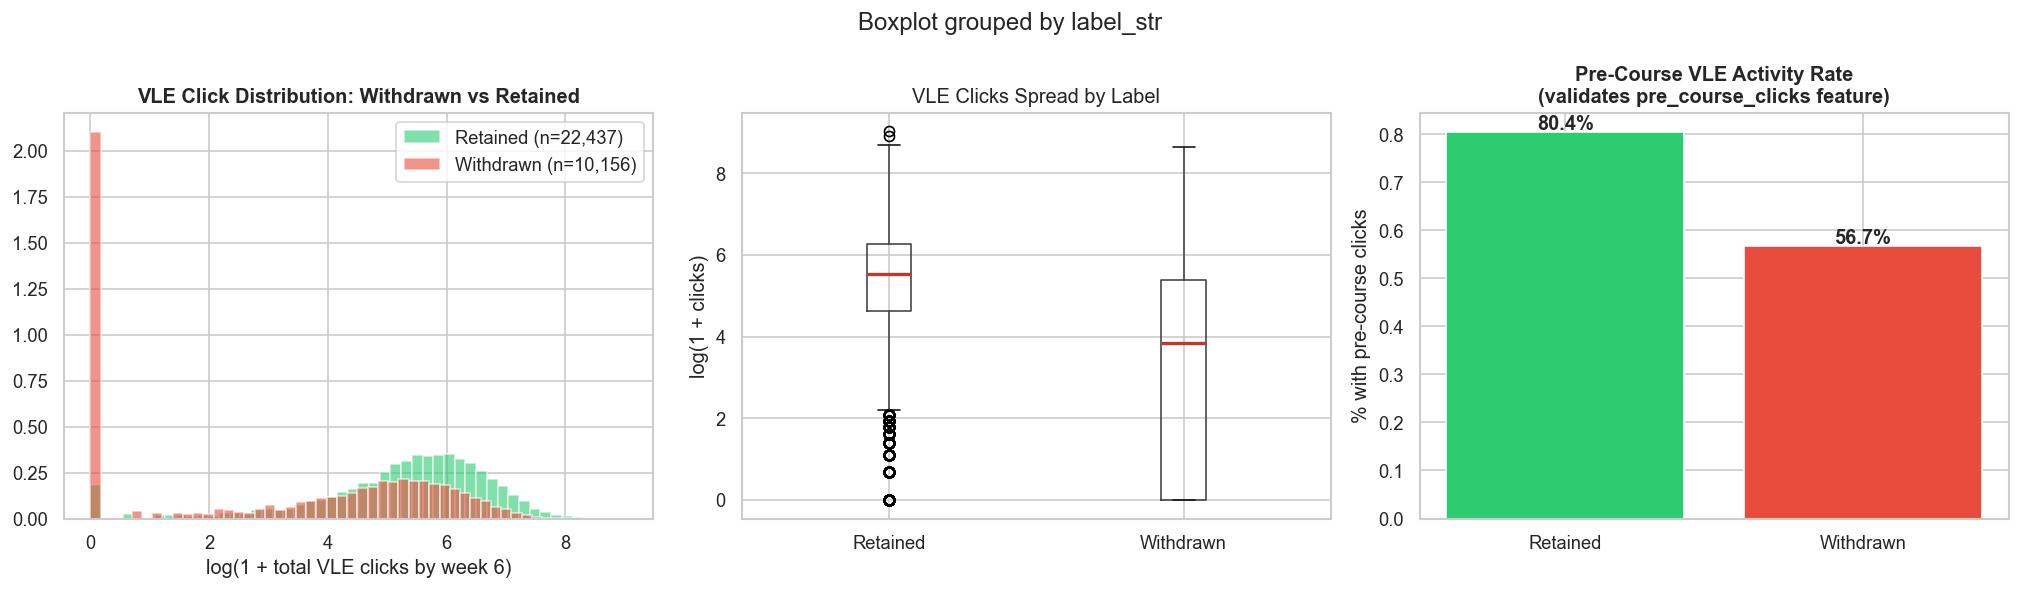

In [6]:
# --- Pre-course clicks (date < 0) ---
pre_course = (
    daily_vle[daily_vle['date'] < 0]
    .groupby(['code_module', 'code_presentation', 'id_student'], observed=True)['sum_click']
    .sum()
    .reset_index()
    .rename(columns={'sum_click': 'pre_course_clicks'})
)

# --- Week-6 total clicks (0 <= date <= 42) ---
student_clicks = (
    daily_vle[(daily_vle['date'] >= 0) & (daily_vle['date'] <= WEEK6_DAY)]
    .groupby(['code_module', 'code_presentation', 'id_student'], observed=True)['sum_click']
    .sum()
    .reset_index()
    .rename(columns={'sum_click': 'total_clicks_w6'})
)

# Merge with info (left join — students with 0 VLE activity get NaN → fill 0)
plot_df = info.merge(student_clicks, on=['code_module', 'code_presentation', 'id_student'], how='left')
plot_df['total_clicks_w6'] = plot_df['total_clicks_w6'].fillna(0)
plot_df = plot_df.merge(pre_course, on=['code_module', 'code_presentation', 'id_student'], how='left')
plot_df['pre_course_clicks'] = plot_df['pre_course_clicks'].fillna(0)

assert len(plot_df) == len(info), f'Row count mismatch after merge: {len(plot_df)} vs {len(info)}'

zero_vle_students = (plot_df['total_clicks_w6'] == 0).sum()
print(f'Students with zero VLE activity by week 6: {zero_vle_students:,} ({zero_vle_students/len(plot_df)*100:.1f}%)')
print(f'Students with pre-course VLE activity: {(plot_df["pre_course_clicks"] > 0).sum():,}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Left: log-distribution by label
for label_val, label_name, color in [(0, 'Retained', '#2ecc71'), (1, 'Withdrawn', '#e74c3c')]:
    subset = plot_df[plot_df['label'] == label_val]
    axes[0].hist(np.log1p(subset['total_clicks_w6']), bins=50, alpha=0.6,
                 label=f'{label_name} (n={len(subset):,})', color=color, density=True)
axes[0].set_xlabel('log(1 + total VLE clicks by week 6)')
axes[0].set_title('VLE Click Distribution: Withdrawn vs Retained', fontweight='bold')
axes[0].legend()

# Middle: boxplot
plot_df['label_str'] = plot_df['label'].map({0: 'Retained', 1: 'Withdrawn'})
plot_df['log_clicks'] = np.log1p(plot_df['total_clicks_w6'])
plot_df.boxplot(column='log_clicks', by='label_str', ax=axes[1],
                medianprops={'color': '#c0392b', 'linewidth': 2})
axes[1].set_title('VLE Clicks Spread by Label', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('log(1 + clicks)')
plt.sca(axes[1])
plt.title('VLE Clicks Spread by Label')

# Right: pre-course activity rate by label
pre_course_rate = plot_df.groupby('label_str', observed=True).apply(
    lambda x: (x['pre_course_clicks'] > 0).mean()
).reset_index()
pre_course_rate.columns = ['label', 'pre_course_rate']
axes[2].bar(pre_course_rate['label'], pre_course_rate['pre_course_rate'],
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[2].set_title('Pre-Course VLE Activity Rate\n(validates pre_course_clicks feature)', fontweight='bold')
axes[2].set_ylabel('% with pre-course clicks')
for i, rate in enumerate(pre_course_rate['pre_course_rate']):
    axes[2].text(i, rate + 0.005, f'{rate:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'vle_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Assessment Timeline vs Day-42 Cutoff

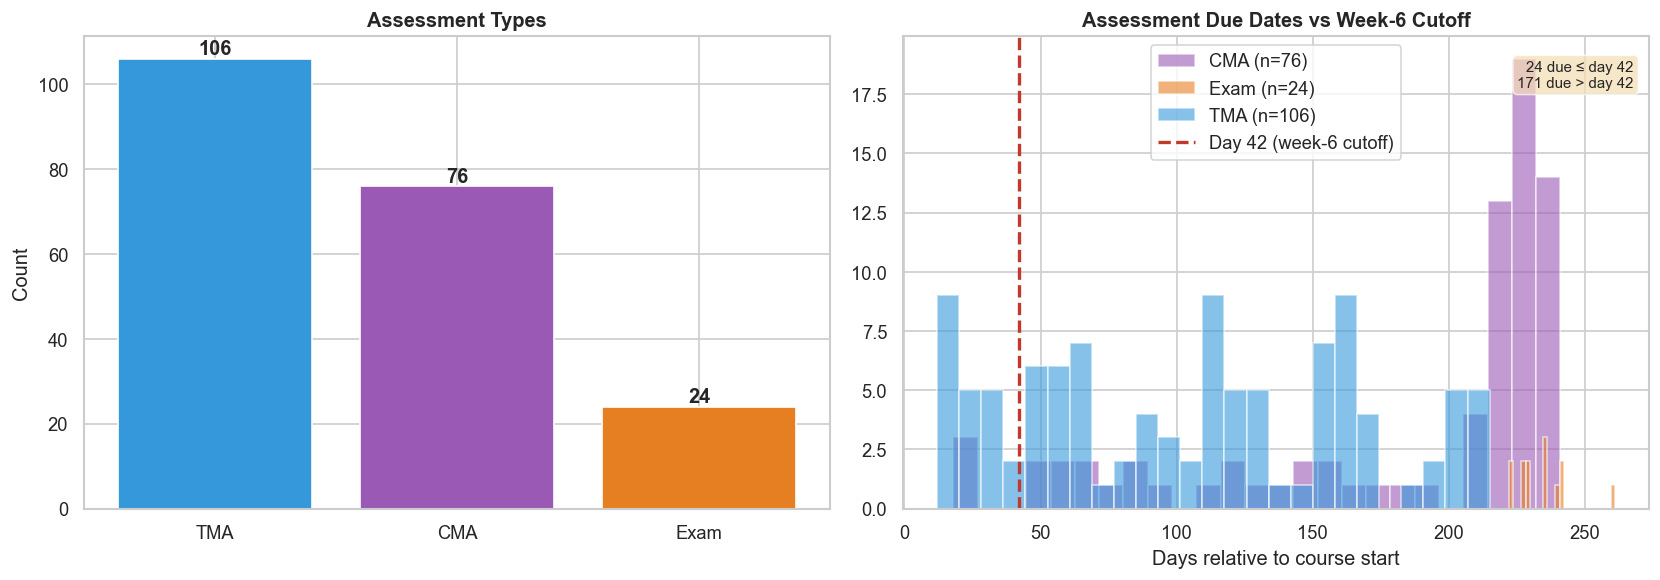

Assessments due on or before day 42: 24
Assessments due after day 42: 171
Confirms week-6 snapshot captures meaningful submission history for all students.


In [7]:
assess_merged = assessments.merge(courses, on=['code_module', 'code_presentation'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: assessment type distribution
type_counts = assessments['assessment_type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='white')
axes[0].set_title('Assessment Types', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(type_counts.items()):
    axes[0].text(i, val + 1, str(val), ha='center', fontweight='bold')

# Right: assessment due dates vs day-42 cutoff
type_colors = {'TMA': '#3498db', 'CMA': '#9b59b6', 'Exam': '#e67e22'}
for atype, group in assess_merged.groupby('assessment_type', observed=True):
    axes[1].hist(group['date'].dropna(), bins=25, alpha=0.6,
                 label=f'{atype} (n={len(group)})', color=type_colors.get(atype, 'gray'))
axes[1].axvline(WEEK6_DAY, color='#c0392b', linestyle='--', linewidth=2,
                label=f'Day {WEEK6_DAY} (week-6 cutoff)')
axes[1].set_xlabel('Days relative to course start')
axes[1].set_title('Assessment Due Dates vs Week-6 Cutoff', fontweight='bold')
axes[1].legend()

# Count assessments before vs after cutoff
before = (assess_merged['date'] <= WEEK6_DAY).sum()
after = (assess_merged['date'] > WEEK6_DAY).sum()
axes[1].text(0.98, 0.95, f'{before} due ≤ day {WEEK6_DAY}\n{after} due > day {WEEK6_DAY}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox={'boxstyle': 'round', 'facecolor': 'wheat', 'alpha': 0.7})

plt.tight_layout()
plt.savefig(FIG_DIR / 'assessment_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Assessments due on or before day {WEEK6_DAY}: {before}')
print(f'Assessments due after day {WEEK6_DAY}: {after}')
print('Confirms week-6 snapshot captures meaningful submission history for all students.')

## Section 7: Correlation Heatmap

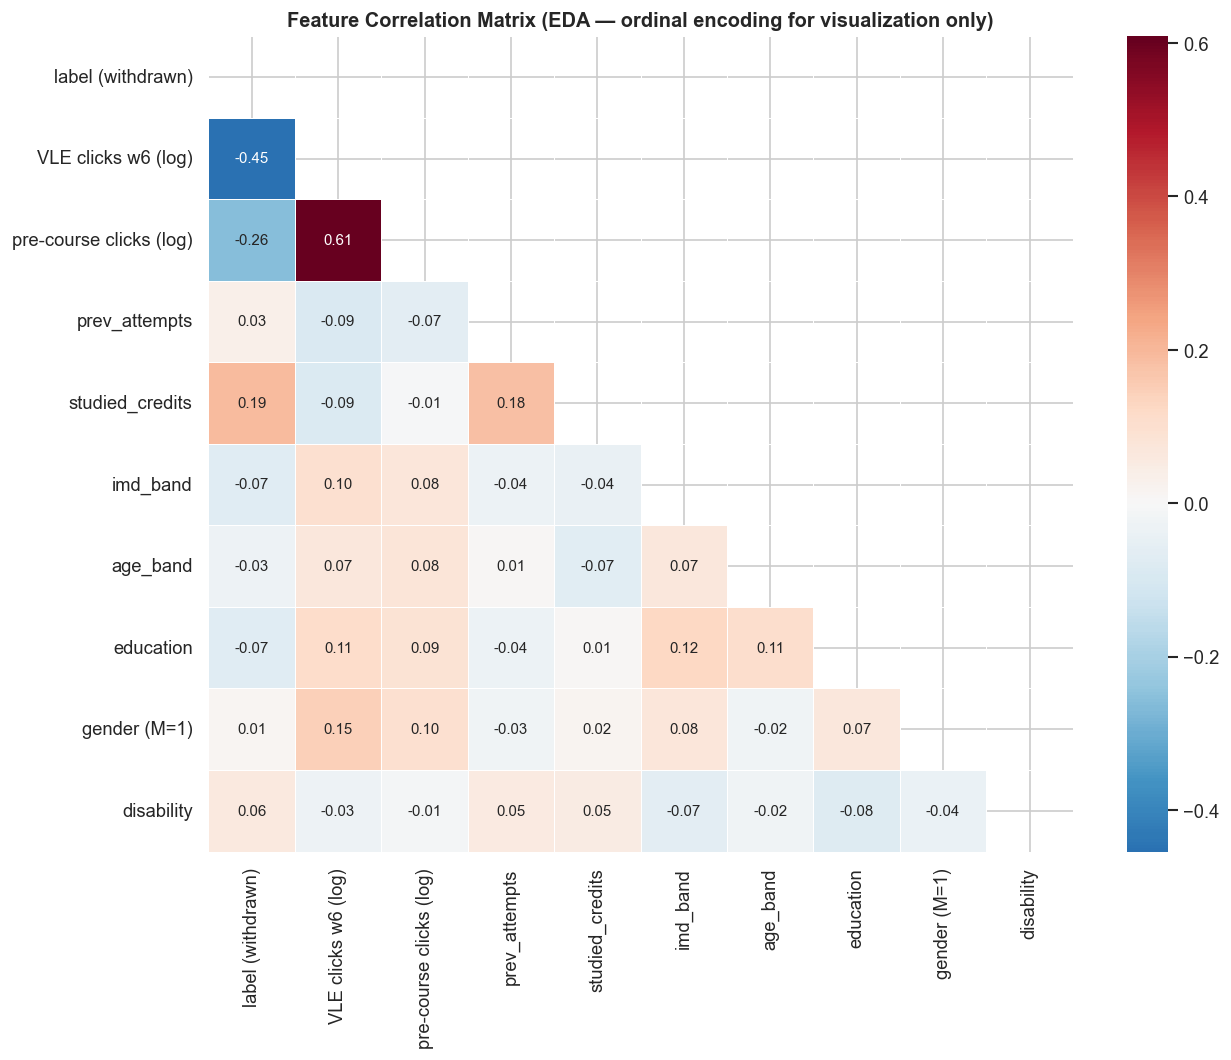

In [8]:
# Ordinal encodings for correlation (not used in model — for EDA only)
imd_order = {
    '0-10%': 1, '10-20%': 2, '20-30%': 3, '30-40%': 4, '40-50%': 5,
    '50-60%': 6, '60-70%': 7, '70-80%': 8, '80-90%': 9, '90-100%': 10
}
age_order = {'0-35': 1, '35-55': 2, '55<=': 3}
edu_order = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}

corr_df = plot_df.copy()
corr_df['imd_band_num'] = corr_df['imd_band'].map(imd_order)
corr_df['age_band_num'] = corr_df['age_band'].map(age_order)
corr_df['edu_num'] = corr_df['highest_education'].map(edu_order)
corr_df['gender_num'] = (corr_df['gender'] == 'M').astype(int)
corr_df['disability_num'] = (corr_df['disability'] == 'Y').astype(int)
corr_df['log_clicks_w6'] = np.log1p(corr_df['total_clicks_w6'])
corr_df['log_pre_course'] = np.log1p(corr_df['pre_course_clicks'])

numeric_cols = [
    'label', 'log_clicks_w6', 'log_pre_course',
    'num_of_prev_attempts', 'studied_credits',
    'imd_band_num', 'age_band_num', 'edu_num', 'gender_num', 'disability_num'
]
col_labels = [
    'label (withdrawn)', 'VLE clicks w6 (log)', 'pre-course clicks (log)',
    'prev_attempts', 'studied_credits',
    'imd_band', 'age_band', 'education', 'gender (M=1)', 'disability'
]

corr_matrix = corr_df[numeric_cols].corr()
corr_matrix.index = col_labels
corr_matrix.columns = col_labels

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    ax=ax, mask=mask, linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title('Feature Correlation Matrix (EDA — ordinal encoding for visualization only)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Multi-Module Enrollment Analysis

In [9]:
# Students appearing in 2+ module-presentations
enrollment_counts = info.groupby('id_student')['code_module'].count()

print('=== Multi-Module Enrollment ===')
print(f'Total training rows (student-module pairs): {len(info):,}')
print(f'Unique students:                            {info["id_student"].nunique():,}')
print(f'Students in exactly 1 module:               {(enrollment_counts == 1).sum():,}')
print(f'Students in 2+ modules:                     {(enrollment_counts > 1).sum():,}')
print(f'Max modules for one student:                {enrollment_counts.max()}')

# Check how many multi-module students have conflicting labels across enrollments
multi_students = enrollment_counts[enrollment_counts > 1].index
multi_df = info[info['id_student'].isin(multi_students)]
conflicting = multi_df.groupby('id_student')['label'].nunique()
print(f'\nMulti-module students with conflicting labels (e.g., Pass in one, Withdrawn in another):')
print(f'  {(conflicting > 1).sum():,} students ({(conflicting > 1).mean()*100:.1f}% of multi-enrollment students)')

print('\n--- Implication for Modeling ---')
print('Train/test split MUST stratify and split on id_student, not on row index.')
print('Otherwise the same student can appear in both train and test via different course enrollments.')

=== Multi-Module Enrollment ===
Total training rows (student-module pairs): 32,593
Unique students:                            28,785
Students in exactly 1 module:               25,247
Students in 2+ modules:                     3,538
Max modules for one student:                5

Multi-module students with conflicting labels (e.g., Pass in one, Withdrawn in another):
  1,488 students (42.1% of multi-enrollment students)

--- Implication for Modeling ---
Train/test split MUST stratify and split on id_student, not on row index.
Otherwise the same student can appear in both train and test via different course enrollments.


## Section 9: Withdrawal Timing (Leakage Check)

Total withdrawn student-module pairs: 10,156
Unregistered on/before day 42 (pre-cutoff): 5,561 (54.8%)
Unregistered after day 42 (post-cutoff):    4,502 (44.3%)
No unregistration date (data quality issue):         93 (0.9%)

--- Feature Leakage Analysis ---
Students who withdrew BEFORE day 42: their post-withdrawal zero-click windows
  are VALID signal (zero activity caused by prior withdrawal is not future leakage).
  Protection: compute ALL features using date <= 42 filter before aggregation.


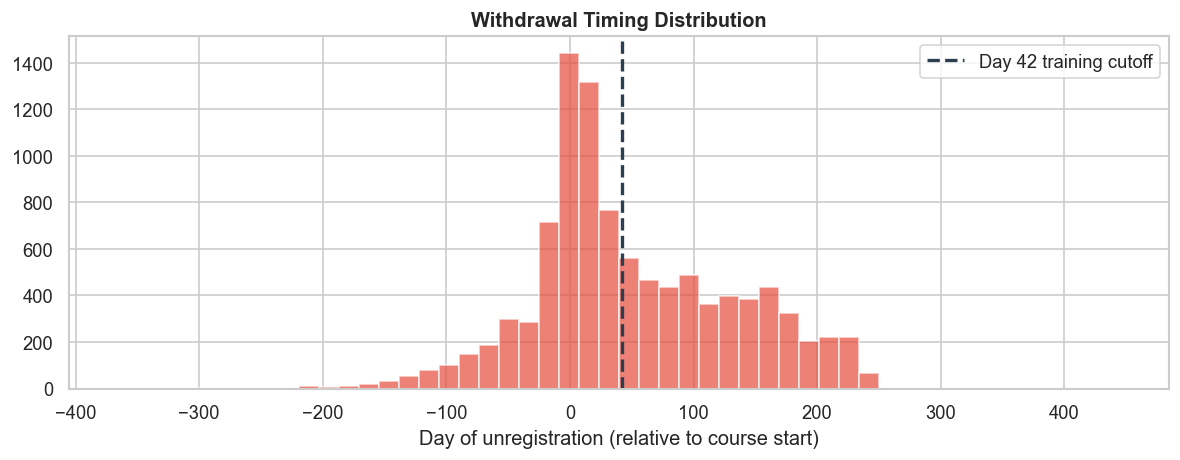

In [10]:
# Merge registration data with labels
reg_merged = info[['code_module', 'code_presentation', 'id_student', 'label']].merge(
    registration, on=['code_module', 'code_presentation', 'id_student'], how='left'
)

withdrawn_only = reg_merged[reg_merged['label'] == 1]
print(f'Total withdrawn student-module pairs: {len(withdrawn_only):,}')
before_cutoff = (withdrawn_only['date_unregistration'] <= WEEK6_DAY).sum()
after_cutoff = (withdrawn_only['date_unregistration'] > WEEK6_DAY).sum()
no_date = withdrawn_only['date_unregistration'].isnull().sum()

print(f'Unregistered on/before day {WEEK6_DAY} (pre-cutoff): {before_cutoff:,} ({before_cutoff/len(withdrawn_only)*100:.1f}%)')
print(f'Unregistered after day {WEEK6_DAY} (post-cutoff):    {after_cutoff:,} ({after_cutoff/len(withdrawn_only)*100:.1f}%)')
print(f'No unregistration date (data quality issue):         {no_date:,} ({no_date/len(withdrawn_only)*100:.1f}%)')

print('\n--- Feature Leakage Analysis ---')
print(f'Students who withdrew BEFORE day {WEEK6_DAY}: their post-withdrawal zero-click windows')
print('  are VALID signal (zero activity caused by prior withdrawal is not future leakage).')
print('  Protection: compute ALL features using date <= 42 filter before aggregation.')

# Timeline plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(withdrawn_only['date_unregistration'].dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
ax.axvline(WEEK6_DAY, color='#2c3e50', linestyle='--', linewidth=2, label=f'Day {WEEK6_DAY} training cutoff')
ax.set_xlabel('Day of unregistration (relative to course start)')
ax.set_title('Withdrawal Timing Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'withdrawal_timing.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: EDA Summary

### Data Quality Findings

| Finding | Detail | Phase 2 Action |
|---------|--------|----------------|
| `imd_band` 3.4% null | 1,111 rows; distributed across modules (MCAR) | Add `imd_band_missing` indicator; impute mode per module-presentation |
| `studentAssessment.score` 0.1% null | 173 rows; non-banked nulls = non-submissions | Impute 0 for non-banked nulls |
| 6,519 students with zero VLE activity | ~20% of pairs; these are real behavioral signals | Fill with 0 after left-join; `days_since_last_vle` = course length |
| Pre-course clicks (date < 0) | Real behavioral signal; students who engage pre-start differ | Extract as `pre_course_clicks` feature |
| Multi-module students | 3,808 students in 2+ modules; ~23% have conflicting labels across enrollments | Split on `id_student` in Phase 3, not on row index |

### Architecture Decisions Confirmed
- **Training unit**: 32,593 student-module pairs (not 28,785 unique students)
- **Training snapshot**: day 42 (week 6); all features filtered to `date <= 42`
- **Label**: `final_result == 'Withdrawn'` → binary 1; `date_unregistration` used only for leakage validation
- **Class imbalance**: 3:1 ratio — revisit SMOTE necessity after baseline model F1 in Phase 3
- **Bias audit primary axis**: IMD deprivation band shows clearest demographic disparity in withdrawal rates

### Phase 2 Feature Engineering Inputs
- `daily_vle`: aggregated to ~2M rows; week checkpoints at days 14, 28, 42, 56
- `student_clicks` + `pre_course`: pre-computed in this notebook, re-derive in Phase 2
- `student_assess` + `assessments`: joined for submission timing and score trends
- `synthetic_features.csv`: merged by `(code_module, code_presentation, id_student)` key